# Sport shapes

Build a marker shape per sport with `gemmini`, convert each to a `shapely` polygon, and plot the fills (no points).

| Sport | Shape |
|---|---|
| run | 10-sided polygon |
| trail run | 10-sided star |
| strength | deep 10-sided star |
| bike | circle |
| hike | 10-sided gear |

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gemmini import RegularPolygon, ConcaveStar, Star, Circle, Gear
from shapely.geometry import Polygon

In [70]:
sides = 12  # number of sides for the regular polygon and star
# Build one gemmini shape per sport.
gem_shapes = {
    "run": Circle(r=10, n=80),  
    "trail run": ConcaveStar(s=10, v=12, n=2),    # 10-sided star
    "strength": Gear(r=10, c=8, n=2),            # deep 10-sided star (intersecting edges)
    "bike": Gear(r=10, c=32, n=2),            # deep 10-sided star (intersecting edges)
    "hike": ConcaveStar(s=10, v=8, n=2),                 # 10-cog gear
}
gem_shapes = {
    "run": Circle(r=10, n=80),  
    "trail run": ConcaveStar(s=10, v=10, n=2),    # 10-sided star
    "strength": Gear(r=10, c=6, n=2),            # deep 10-sided star (intersecting edges)
    "bike": Gear(r=10, c=16, n=2),            # deep 10-sided star (intersecting edges)
    "hike": ConcaveStar(s=10, v=6, n=2),                 # 10-cog gear
}


def to_shapely(obj):
    """Convert a gemmini shape to a valid shapely Polygon."""
    poly = Polygon(np.asarray(obj.coords()))
    if not poly.is_valid:
        # The deep star has self-intersecting edges; buffer(0) resolves it
        # into a clean outline while keeping the deep notches.
        poly = poly.buffer(0)
    return poly


shapes = {name: to_shapely(obj) for name, obj in gem_shapes.items()}
for name, poly in shapes.items():
    print(f"{name:10} valid={poly.is_valid}  area={poly.area:6.1f}")

# shapes['strength'] = shapes['strength'].buffer(2).buffer(-2)
shapes['strength'] = shapes['strength'].buffer(3).buffer(-3)


# shapes['bike'] = shapes['bike'].buffer(-0.4).buffer(0.5)
shapes['bike'] = shapes['bike'].buffer(-0.4).buffer(0.7)

shapes['hike'] = shapes['hike'].buffer(-1).buffer(6).buffer(-3)

run        valid=True  area= 313.8
trail run  valid=True  area= 262.9
strength   valid=True  area= 246.9
bike       valid=True  area= 292.5
hike       valid=True  area= 173.2


In [71]:
# shapes['strength'] = shapes['strength'].buffer(-2).buffer(2).buffer(-2)
# shapes['hike'] = shapes['hike'].buffer(1)

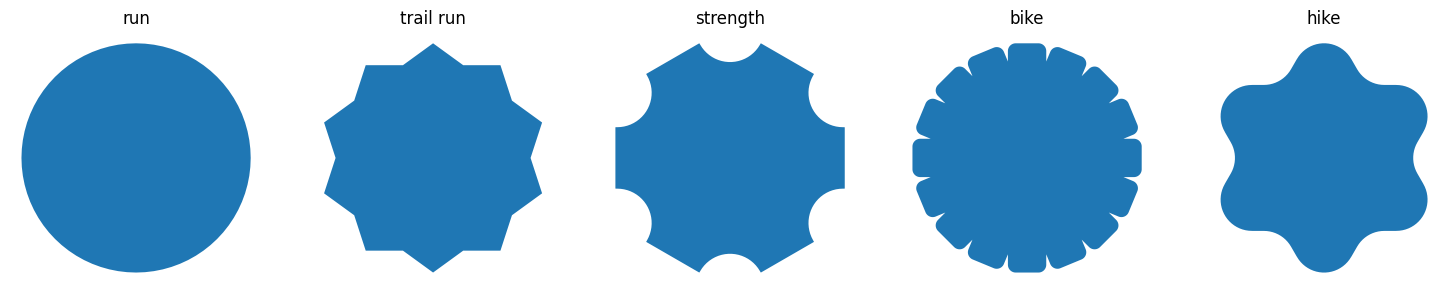

In [72]:
# Plot the fills only (no points).
fig, axes = plt.subplots(1, len(shapes), figsize=(3 * len(shapes), 3))

for ax, (name, poly) in zip(axes, shapes.items()):
    x, y = poly.exterior.xy
    ax.fill(x, y)
    ax.set_title(name)
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()
plt.show()